<a href="https://colab.research.google.com/github/HarshithReddy01/Algorithms-Practice/blob/master/adaline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data',
    header=None)
print(df.head(10))
print("Shape: ", df.shape)

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
5  5.4  3.9  1.7  0.4  Iris-setosa
6  4.6  3.4  1.4  0.3  Iris-setosa
7  5.0  3.4  1.5  0.2  Iris-setosa
8  4.4  2.9  1.4  0.2  Iris-setosa
9  4.9  3.1  1.5  0.1  Iris-setosa
Shape:  (150, 5)


In [3]:
y = df.iloc[0:100, 4].values
print("Flower names:", np.unique(y))
y = np.where(y == 'Iris-setosa', -1, 1)
print("After converting:", y[:10])

Flower names: ['Iris-setosa' 'Iris-versicolor']
After converting: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


In [4]:
X = df.iloc[0:100, [0, 2]].values
print("Features shape:", X.shape)
print("First 5 rows:\n", X[:5])

Features shape: (100, 2)
First 5 rows:
 [[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]


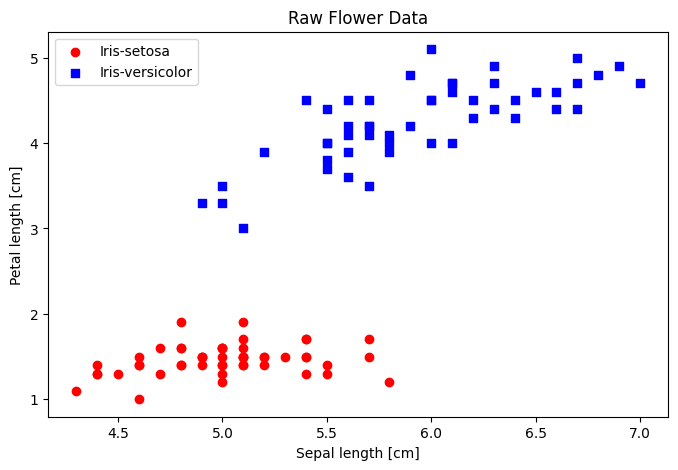

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:50, 0], X[:50, 1],
            color='red', marker='o', label='Iris-setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color='blue', marker='s', label='Iris-versicolor')

plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.title('Raw Flower Data')
plt.show()

In [6]:
"""Adaline"""

class AdalineGD:
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=X.shape[1])
        self.b_ = np.float64(0.)
        self.losses_ = []

        for _ in range(self.n_iter):
            output = self.activation(self.net_input(X))
            errors = (y - output)
            self.w_ += self.eta * 2.0 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2.0 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_) + self.b_

    def activation(self, X):
        return X

    def predict(self, X):
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, -1)

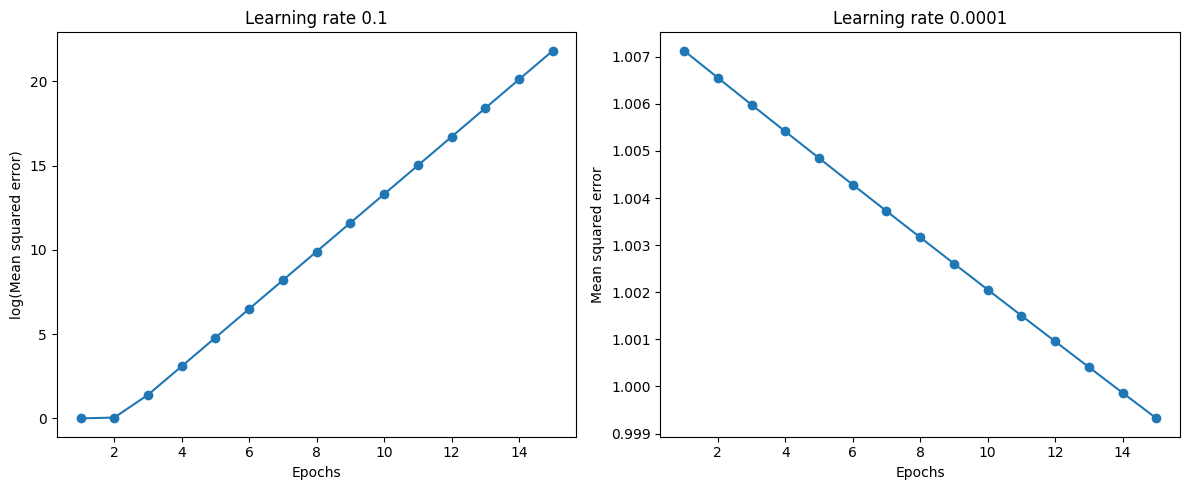

In [7]:
ada_big = AdalineGD(n_iter=15, eta=0.1)
ada_big.fit(X, y)

ada_small = AdalineGD(n_iter=15, eta=0.0001)
ada_small.fit(X, y)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(range(1, len(ada_big.losses_) + 1), np.log10(ada_big.losses_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Mean squared error)')
ax[0].set_title('Learning rate 0.1')

ax[1].plot(range(1, len(ada_small.losses_) + 1), ada_small.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Learning rate 0.0001')

plt.tight_layout()
plt.show()

In [8]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

print("Before:", X[:5])
print("After:", X_std[:5])

Before: [[5.1 1.4]
 [4.9 1.4]
 [4.7 1.3]
 [4.6 1.5]
 [5.  1.4]]
After: [[-0.5810659  -1.01435952]
 [-0.89430898 -1.01435952]
 [-1.20755205 -1.08374115]
 [-1.36417359 -0.94497788]
 [-0.73768744 -1.01435952]]


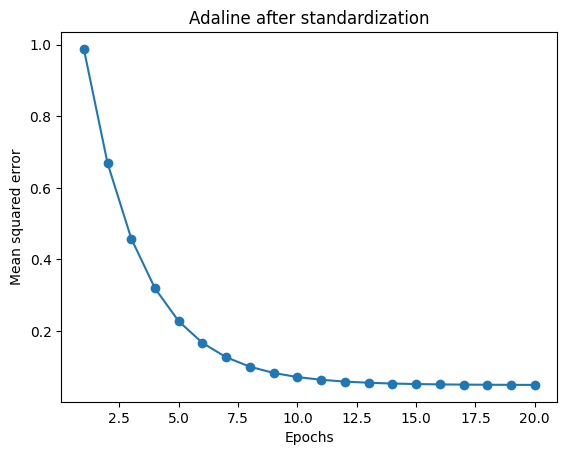

In [9]:
ada_gd = AdalineGD(n_iter=20, eta=0.5)
ada_gd.fit(X_std, y)

plt.plot(range(1, len(ada_gd.losses_) + 1), ada_gd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean squared error')
plt.title('Adaline after standardization')
plt.show()

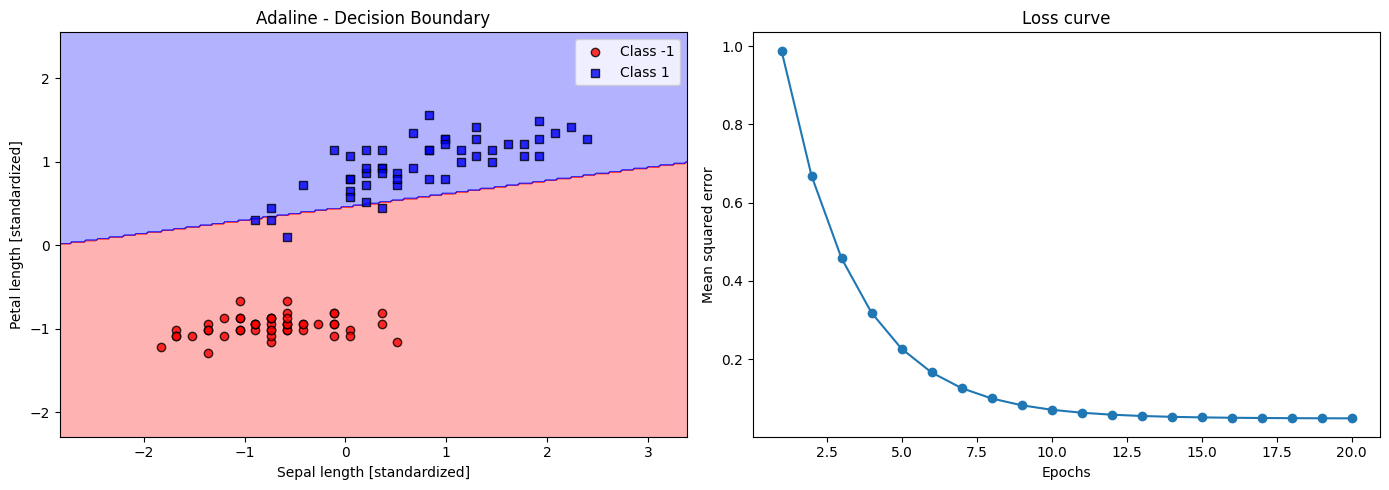

In [10]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    markers = ('o', 's')
    colors = ('red', 'blue')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(X[y == cl, 0], X[y == cl, 1],
                    alpha=0.8, c=colors[idx], marker=markers[idx], label=f'Class {cl}', edgecolor='black')

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

plt.sca(ax[0])
plot_decision_regions(X_std, y, classifier=ada_gd)
ax[0].set_xlabel('Sepal length [standardized]')
ax[0].set_ylabel('Petal length [standardized]')
ax[0].set_title('Adaline - Decision Boundary')
ax[0].legend()

ax[1].plot(range(1, len(ada_gd.losses_) + 1), ada_gd.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Loss curve')

plt.tight_layout()
plt.show()